In [66]:
import os
import pandas as pd
import joblib
import config
import numpy as np
from scipy import stats
from itertools import combinations
from sklearn.compose import ColumnTransformer

from preprocessing_utils import *

In [67]:
# X_train, y_train, X_val, y_val, X_test, y_test, clinical_cols, mrna_cols, mutation_cols = load_and_split_data()
# os.makedirs(config.SPLIT_DATA_DIR, exist_ok=True)

# # Save all artifacts in the new folder
# joblib.dump(X_train, os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
# joblib.dump(y_train, os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
# joblib.dump(X_val, os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
# joblib.dump(y_val, os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
# joblib.dump(X_test, os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
# joblib.dump(y_test, os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))
# joblib.dump(clinical_cols, os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
# joblib.dump(mrna_cols, os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
# joblib.dump(mutation_cols, os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

In [90]:
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
clinical_df = X_train[clinical_cols]
mrna_df = X_train[mrna_cols]


In [69]:
print("hello worls")
print(len(mrna_cols))
print(len(mrna_df))

hello worls
20531
147


In [70]:
uniform_cols = [col for col in clinical_df.columns 
                if clinical_df[col].nunique(dropna=True) <= 1]

print("Fully uniform columns (defined by containing all one value (excluding NaNs): ", uniform_cols)


Fully uniform columns (defined by containing all one value (excluding NaNs):  ['CANCER_TYPE_ACRONYM', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'HISTORY_NEOADJUVANT_TRTYN', 'INFORMED_CONSENT_VERIFIED', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT']


In [71]:
clinical_df = clinical_df.drop(columns=uniform_cols, errors="ignore")
clinical_df = clinical_df.drop(columns=config.CLINICAL_COLS_TO_REMOVE, errors='ignore')

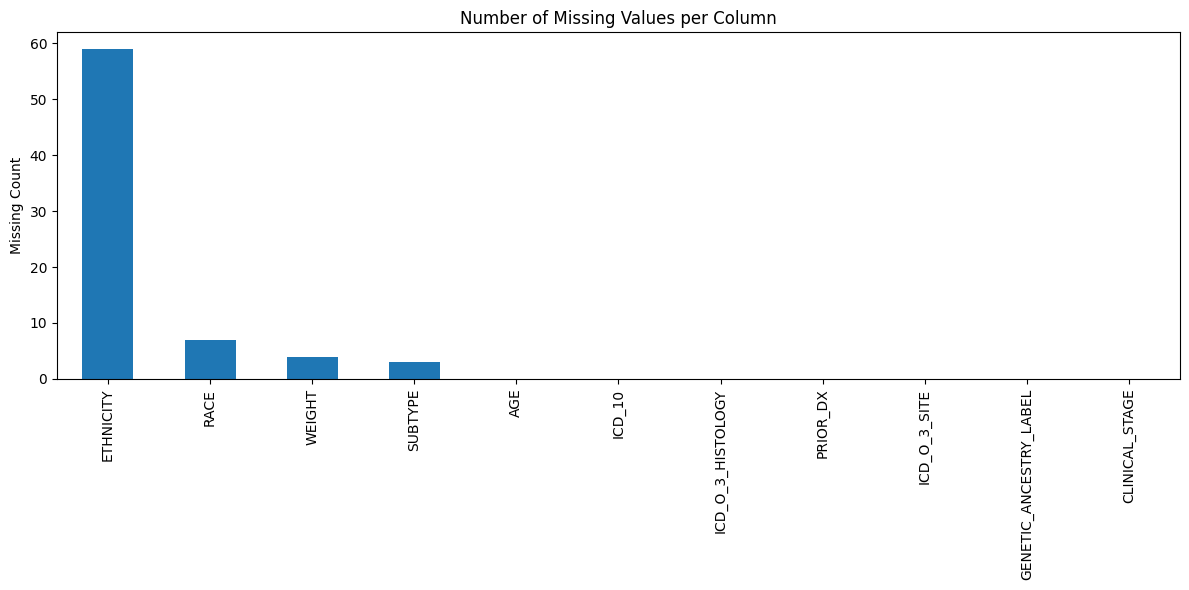

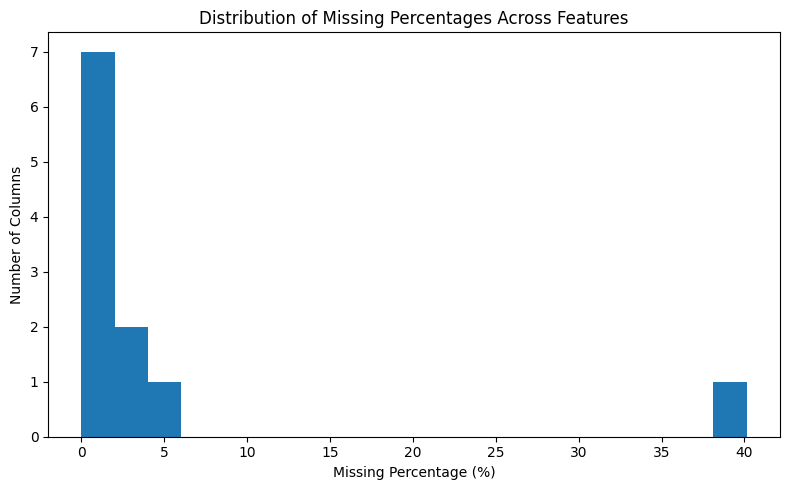

,missing_count,missing_pct
ETHNICITY,59,40.136054
RACE,7,4.761905
WEIGHT,4,2.721088
SUBTYPE,3,2.040816
AGE,0,0.000000
ICD_10,0,0.000000
ICD_O_3_HISTOLOGY,0,0.000000
PRIOR_DX,0,0.000000
ICD_O_3_SITE,0,0.000000
GENETIC_ANCESTRY_LABEL,0,0.000000


In [72]:
import pandas as pd
import matplotlib.pyplot as plt


# --- Missingness calculations ---
missing_counts = clinical_df.isna().sum().sort_values(ascending=False)
missing_pct = (clinical_df.isna().mean() * 100).sort_values(ascending=False)

# ========== 1. Bar plot of missing counts per column ==========
plt.figure(figsize=(12, 6))
missing_counts.plot(kind='bar')
plt.title("Number of Missing Values per Column")
plt.ylabel("Missing Count")
plt.tight_layout()
plt.show()

# ========== 2. Histogram of missing % across features ==========
plt.figure(figsize=(8, 5))
plt.hist(missing_pct, bins=20)  # *No color specified (as per your style guidelines)
plt.title("Distribution of Missing Percentages Across Features")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Columns")
plt.tight_layout()
plt.show()

# (Optional) Print top missing features to inspect
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

missing_summary

# Really the only column here that is wouldn't otherwise be removed and should is ETHNICITY

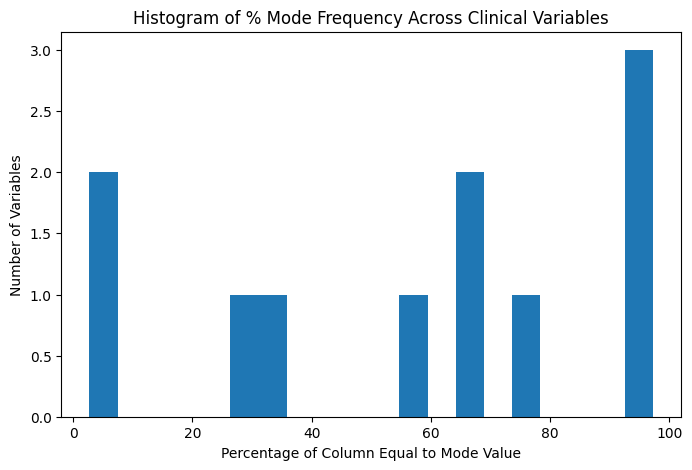

ICD_10                    97.278912
ICD_O_3_SITE              97.278912
PRIOR_DX                  93.877551
ICD_O_3_HISTOLOGY         74.829932
GENETIC_ANCESTRY_LABEL    66.666667
RACE                      65.306122
ETHNICITY                 55.782313
SUBTYPE                   34.693878
CLINICAL_STAGE            27.210884
AGE                        6.122449
dtype: float64


In [73]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mode_frequency_histogram(df):
    """
    Computes the % of rows that are equal to the mode value for each column
    and plots a histogram of those percentages.
    """

    mode_freqs = []

    for col in df.columns:
        # Skip columns that can't have a mode frequency (like all NaN or non-hashable)
        try:
            mode_val = df[col].mode(dropna=True)
            if len(mode_val) == 0:
                continue

            mode_val = mode_val.iloc[0]
            freq = (df[col] == mode_val).mean() * 100  # percent
            mode_freqs.append(freq)
        except Exception:
            continue

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(mode_freqs, bins=20)
    plt.xlabel("Percentage of Column Equal to Mode Value")
    plt.ylabel("Number of Variables")
    plt.title("Histogram of % Mode Frequency Across Clinical Variables")
    plt.show()

    return pd.Series(mode_freqs, index=df.columns[:len(mode_freqs)])

mode_freq_series = plot_mode_frequency_histogram(clinical_df)

# Sort descending (most uniform first)
mode_freq_sorted = mode_freq_series.sort_values(ascending=False)

# View top 10 most uniform variables
print(mode_freq_sorted.head(10))


In [74]:
# Combine the column and labels into a temporary dataframe
temp = pd.DataFrame({
    "PRIOR_DX": clinical_df["PRIOR_DX"],
    "Recurrence": y_train
})

# Drop missing values if any
temp = temp.dropna(subset=["PRIOR_DX", "Recurrence"])

# Compute recurrence rates for each group
recurrence_rates = temp.groupby("PRIOR_DX")["Recurrence"].mean() * 100

# Also count number of patients in each group
counts = temp["PRIOR_DX"].value_counts()

print("Counts by PRIOR_DX:")
print(counts)
print("\nRecurrence rates by PRIOR_DX (%):")
print(recurrence_rates)


Counts by PRIOR_DX:
PRIOR_DX
No     138
Yes      9
Name: count, dtype: int64

Recurrence rates by PRIOR_DX (%):
PRIOR_DX
No     36.231884
Yes    33.333333
Name: Recurrence, dtype: float64


/tmp/ipykernel_1089376/1728733673.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Before Imputation', 'After Imputation'])


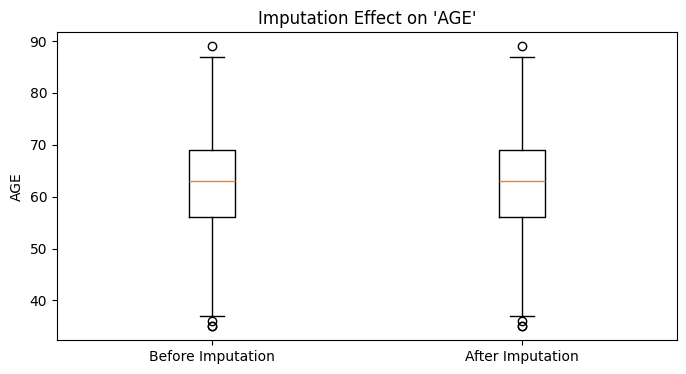

/tmp/ipykernel_1089376/1728733673.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Before Imputation', 'After Imputation'])


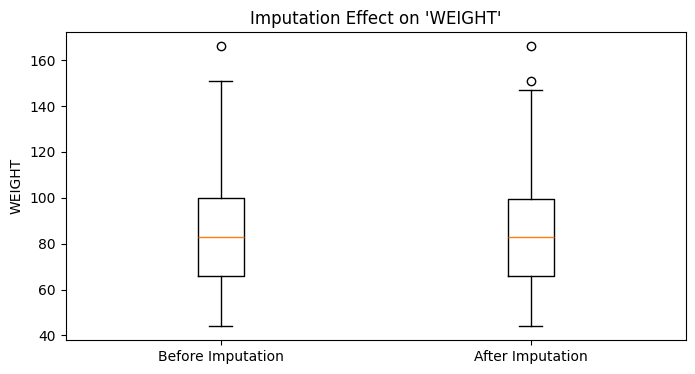

In [75]:
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = clinical_df.select_dtypes(include=["number"]).columns

# Impute missing values with median
after_impute = clinical_df[numeric_cols].fillna(clinical_df[numeric_cols].median())

# Plot boxplots before vs after imputation
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    
    # Combine data for plotting
    data_to_plot = [clinical_df[col].dropna(), after_impute[col]]
    
    plt.boxplot(data_to_plot, labels=['Before Imputation', 'After Imputation'])
    plt.title(f"Imputation Effect on '{col}'")
    plt.ylabel(col)
    plt.show()

### mrna Data Exploration

In [91]:
print("Number of mRNA expression columns:", len(mrna_cols))
all_nan_cols = mrna_df.columns[mrna_df.isna().all()]
print(f"Number of columns that are all NaN: {len(all_nan_cols)}")
mrna_df = mrna_df.drop(columns=all_nan_cols)
uniform_cols = [col for col in mrna_df.columns 
                if mrna_df[col].nunique(dropna=True) <= 1]
print("Total number of uniform columns (only one value excluding NaNs):", len(uniform_cols))
mrna_df = mrna_df.drop(columns=uniform_cols)

# Count columns with no NaNs
no_nan_cols = (mrna_df.isna().sum() == 0).sum()

# Compute percent NaNs for the remaining columns
nan_percent = mrna_df.isna().sum() / mrna_df.shape[0] * 100

# Print value counts
print("Value counts for percent NaN:")
print(nan_percent.value_counts())

# mrna_df = mrna_df.loc[:, mrna_df.isna().sum() == 0] # Only Keeping genes with no NaN values

print("Final mRNA expression feature count: ", len(mrna_df.columns))

Number of mRNA expression columns: 20531
Number of columns that are all NaN: 510
Total number of uniform columns (only one value excluding NaNs): 223
Value counts for percent NaN:
0.000000     17507
78.231293     2291
Name: count, dtype: int64
Final mRNA expression feature count:  19798


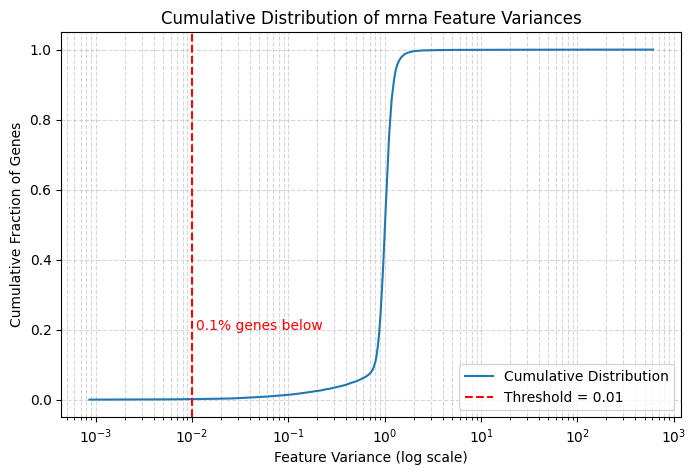

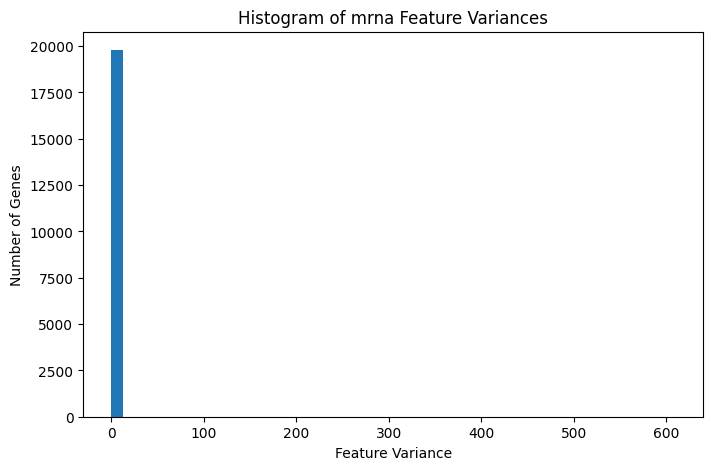

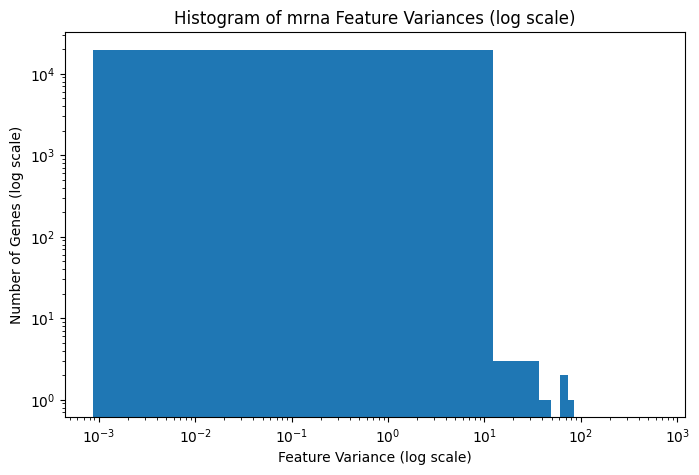

Minimum variance: 8.65e-04
Maximum variance: 6.10e+02
Mean variance: 1.05e+00
Median variance: 1.01e+00


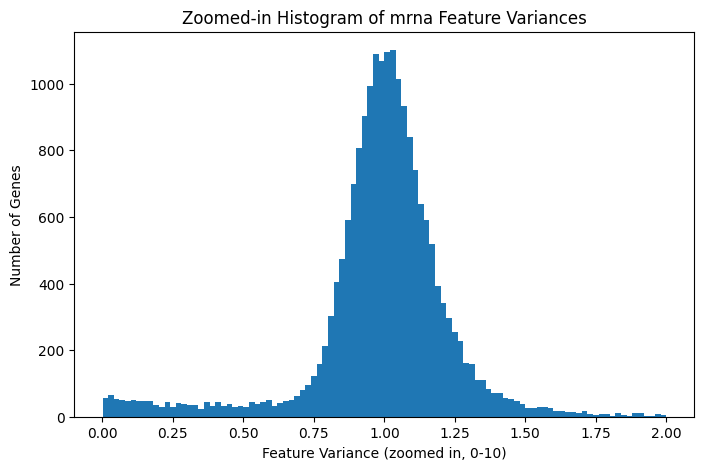

Number of genes with variance > 10: 91
Top 10 most variable genes:
OR2M1P        609.679629
SNORA69        85.116019
LCE1D          72.588598
OR4C16         67.925340
OR6Y1          48.257944
KRTAP10-12     33.235093
PATE1          29.977605
POTEA          27.889246
HTN3           19.345308
CETN1          19.239690
dtype: float64
OR2M1P is expressed in 1 out of 147 samples (0.68%)


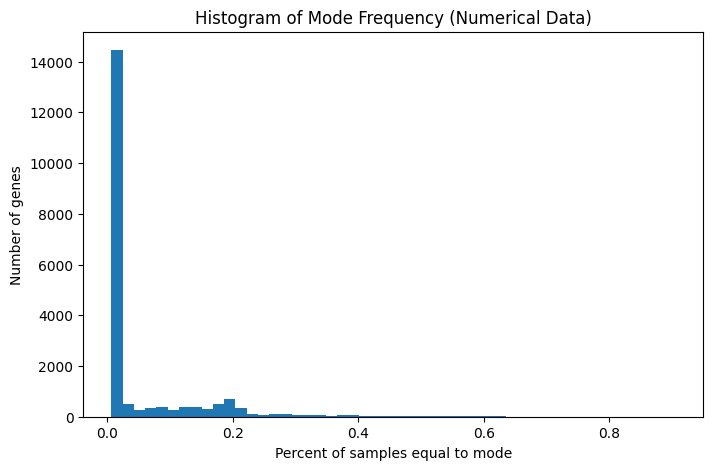

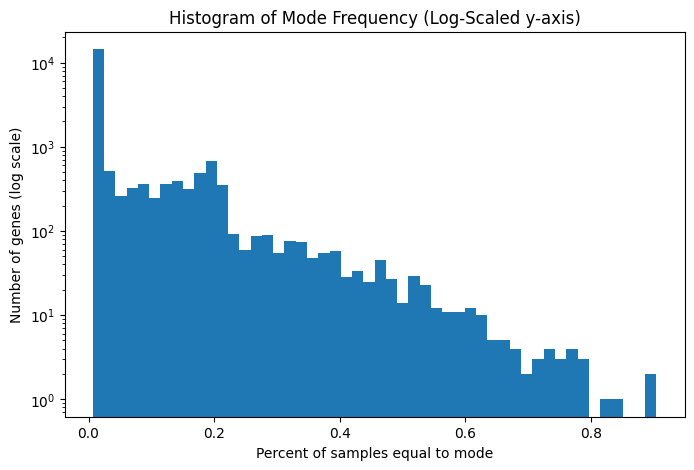

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming mrna_df contains only the mrna features (no labels)
variances = mrna_df.var(axis=0)

# Sort variances for cumulative distribution
sorted_variances = np.sort(variances)
cumulative = np.arange(1, len(sorted_variances)+1) / len(sorted_variances)

# Plot cumulative distribution
plt.figure(figsize=(8, 5))
plt.plot(sorted_variances, cumulative, label="Cumulative Distribution")
plt.xscale("log")
plt.xlabel("Feature Variance (log scale)")
plt.ylabel("Cumulative Fraction of Genes")
plt.title("Cumulative Distribution of mrna Feature Variances")
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Highlight variance threshold
variance_threshold = 0.01
plt.axvline(x=variance_threshold, color="red", linestyle="--", label=f"Threshold = {variance_threshold}")

# Show fraction of genes below threshold
fraction_below = (variances < variance_threshold).mean()
plt.text(variance_threshold*1.1, 0.2, f"{fraction_below*100:.1f}% genes below", color="red")

plt.legend()
plt.show()

variances = mrna_df.var(axis=0)

# 1. Histogram of feature variances
plt.figure(figsize=(8, 5))
plt.hist(variances, bins=50)
plt.xlabel("Feature Variance")
plt.ylabel("Number of Genes")
plt.title("Histogram of mrna Feature Variances")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(variances, bins=50, log=True)  # log scale for y-axis
plt.xscale("log")                        # log scale for x-axis
plt.xlabel("Feature Variance (log scale)")
plt.ylabel("Number of Genes (log scale)")
plt.title("Histogram of mrna Feature Variances (log scale)")
plt.show()

print(f"Minimum variance: {variances.min():.2e}")
print(f"Maximum variance: {variances.max():.2e}")
print(f"Mean variance: {variances.mean():.2e}")
print(f"Median variance: {variances.median():.2e}")

import matplotlib.pyplot as plt

# Zoomed-in histogram (0 to 10 variance)
plt.figure(figsize=(8, 5))
plt.hist(variances[variances <= 2], bins=100)
plt.xlabel("Feature Variance (zoomed in, 0-10)")
plt.ylabel("Number of Genes")
plt.title("Zoomed-in Histogram of mrna Feature Variances")
plt.show()

# Optional: show number of genes with variance > 10
num_high_variance = (variances > 2).sum()
print(f"Number of genes with variance > 10: {num_high_variance}")

# Compute variances
variances = mrna_df.var(axis=0)

# Sort variances descending and get top 10
top10_genes = variances.sort_values(ascending=False).head(10)

print("Top 10 most variable genes:")
print(top10_genes)

# Count number of samples with non-zero expression
nonzero_count = (mrna_df["LCE1D"] > 0).sum()
total_samples = mrna_df.shape[0]

print(f"OR2M1P is expressed in {nonzero_count} out of {total_samples} samples "
      f"({nonzero_count/total_samples*100:.2f}%)")

import numpy as np
import matplotlib.pyplot as plt

# Compute percent of samples that equal the mode for each gene
mode_freq = []

for col in mrna_df.columns:
    # get most common value (the mode)
    mode_value = mrna_df[col].mode(dropna=True)

    if len(mode_value) == 0:
        freq = 0
    else:
        mode_value = mode_value.iloc[0]
        freq = (mrna_df[col] == mode_value).mean()  # fraction
        
    mode_freq.append(freq)

mode_freq = np.array(mode_freq)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(mode_freq, bins=50)
plt.xlabel("Percent of samples equal to mode")
plt.ylabel("Number of genes")
plt.title("Histogram of Mode Frequency (Numerical Data)")
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Compute percent mode frequency for each gene
mode_freq = []

for col in mrna_df.columns:
    mode_value = mrna_df[col].mode(dropna=True)
    if len(mode_value) == 0:
        freq = 0
    else:
        mode_value = mode_value.iloc[0]
        freq = (mrna_df[col] == mode_value).mean()
    mode_freq.append(freq)

mode_freq = np.array(mode_freq)

# Histogram with log-scale y-axis
plt.figure(figsize=(8, 5))
plt.hist(mode_freq, bins=50)
plt.yscale("log")  # <<< change here
plt.xlabel("Percent of samples equal to mode")
plt.ylabel("Number of genes (log scale)")
plt.title("Histogram of Mode Frequency (Log-Scaled y-axis)")
plt.show()


Number of genes with >50% mode frequency: 148


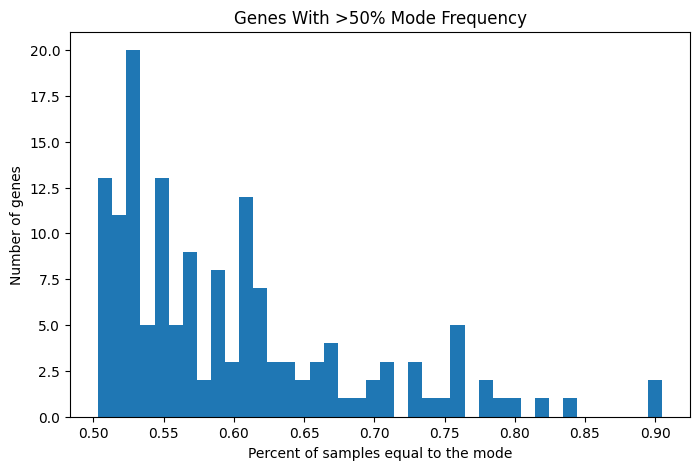

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Compute percent mode frequency for each gene
mode_freq = []

for col in mrna_df.columns:
    mode_value = mrna_df[col].mode(dropna=True)
    if len(mode_value) == 0:
        freq = 0
    else:
        mode_value = mode_value.iloc[0]
        freq = (mrna_df[col] == mode_value).mean()
    mode_freq.append(freq)

mode_freq = np.array(mode_freq)

# Filter for genes dominated by their mode (>50% identical)
high_mode = mode_freq[mode_freq > 0.5]

print(f"Number of genes with >50% mode frequency: {len(high_mode)}")

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(high_mode, bins=40)
plt.xlabel("Percent of samples equal to the mode")
plt.ylabel("Number of genes")
plt.title("Genes With >50% Mode Frequency")
plt.show()


TEX13A      0.968750
FKSG29      0.968750
FLJ46321    0.968750
RNASE8      0.968750
RNASE12     0.968750
              ...   
ZNHIT1      0.006803
ZNHIT3      0.006803
ZNHIT6      0.006803
ZNF879      0.006803
ZNF880      0.006803
Length: 19798, dtype: float64


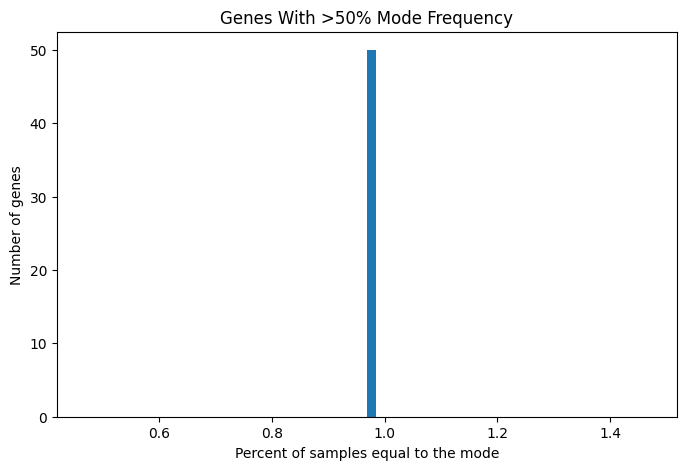

In [94]:
import pandas as pd

def compute_mode_frequencies(df):
    """
    Computes, for each column of df, the fraction of non-NaN values
    that are equal to that column's mode.

    Returns a sorted Series with the highest frequencies first.
    """
    mode_freq = {}

    for col in df.columns:
        series = df[col].dropna()

        # If the column is empty or all NaN → skip
        if series.empty:
            mode_freq[col] = float('nan')
            continue
        
        # Compute the mode — take the first if multiple modes exist
        mode_val = series.mode().iloc[0]

        # Count how many values equal the mode
        count_equal = (series == mode_val).sum()

        # Compute frequency
        freq = count_equal / len(series)
        mode_freq[col] = freq

    # Convert to pandas Series, sort descending
    mode_freq = pd.Series(mode_freq).sort_values(ascending=False)

    return mode_freq

top_genes = compute_mode_frequencies(mrna_df)
print(top_genes)


plt.figure(figsize=(8, 5))
plt.hist(top_genes.head(50), bins=60)
plt.xlabel("Percent of samples equal to the mode")
plt.ylabel("Number of genes")
plt.title("Genes With >50% Mode Frequency")
plt.show()


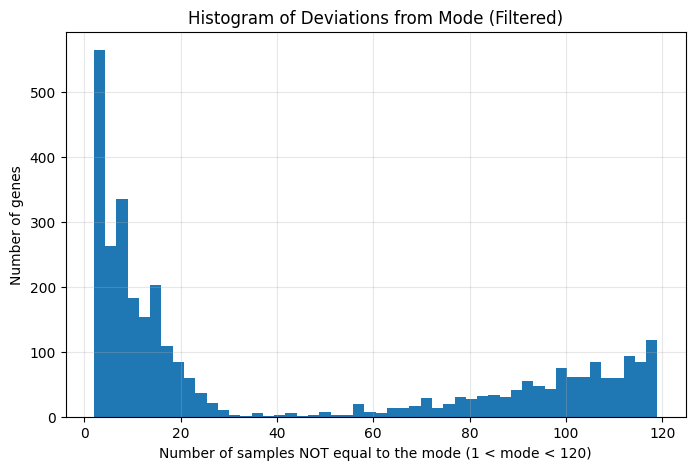

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Compute raw non-mode counts
non_mode_counts = {}

for col in mrna_df.columns:
    series = mrna_df[col].dropna()
    if series.empty:
        non_mode_counts[col] = 0
        continue

    mode_val = series.mode().iloc[0]
    mode_count = (series == mode_val).sum()
    non_mode_counts[col] = len(series) - mode_count

# Convert to array
non_mode_vals = np.array(list(non_mode_counts.values()))

# Filter: keep only those < 120
half_filtered = non_mode_vals[non_mode_vals < 120]
filtered_vals = half_filtered[half_filtered > 1]

# Plot
plt.figure(figsize=(8,5))
plt.hist(filtered_vals, bins=50)
plt.xlabel("Number of samples NOT equal to the mode (1 < mode < 120)")
plt.ylabel("Number of genes")
plt.title("Histogram of Deviations from Mode (Filtered)")
plt.grid(True, alpha=0.3)
plt.show()


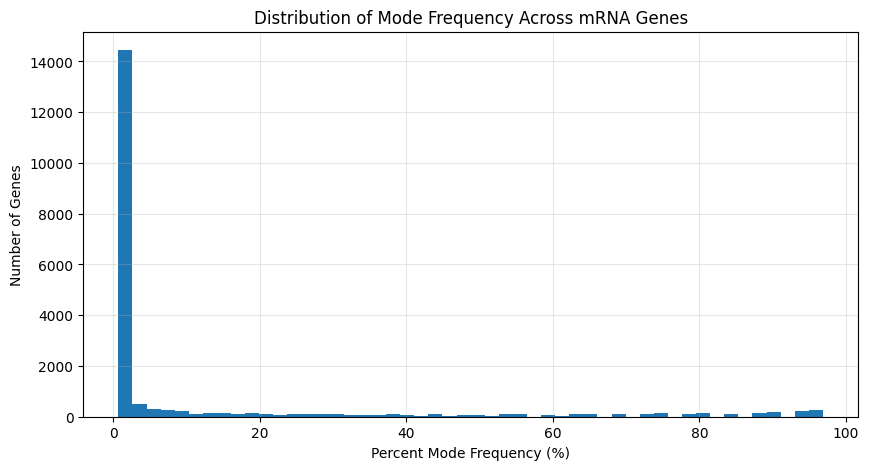

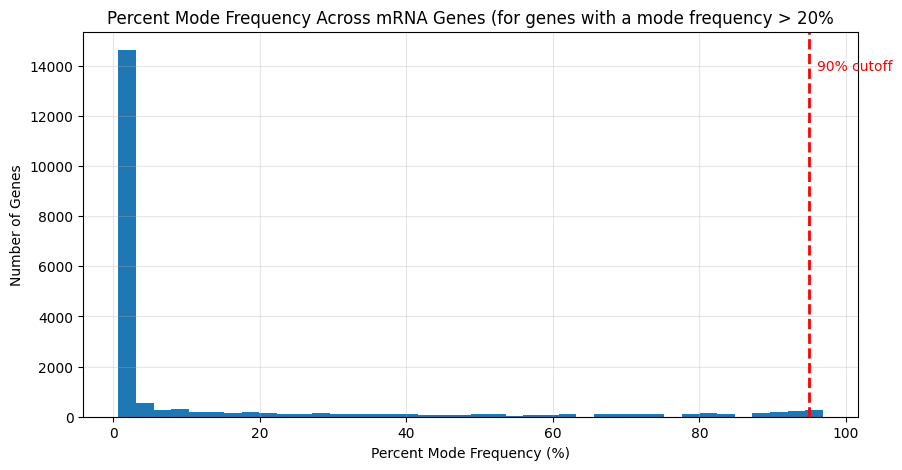

In [96]:
import matplotlib.pyplot as plt

def compute_mode_frequencies(df):
    """
    Computes, for each column of df, the fraction of non-NaN values
    that are equal to that column's mode.

    Returns a sorted Series with the highest frequencies first.
    """
    mode_freq = {}

    for col in df.columns:
        series = df[col].dropna()

        # If the column is empty or all NaN → skip
        if series.empty:
            mode_freq[col] = float('nan')
            continue
        
        # Compute the mode — take the first if multiple modes exist
        mode_val = series.mode().iloc[0]

        # Count how many values equal the mode
        count_equal = (series == mode_val).sum()

        # Compute frequency
        freq = count_equal / len(series)
        mode_freq[col] = freq

    # Convert to pandas Series, sort descending
    mode_freq = pd.Series(mode_freq).sort_values(ascending=False)

    return mode_freq

mode_freq = compute_mode_frequencies(mrna_df)
# mode_freq = mode_freq[mode_freq > .1]

plt.figure(figsize=(10, 5))
plt.hist(mode_freq.values * 100, bins=50)   # convert to percent
plt.xlabel("Percent Mode Frequency (%)")
plt.ylabel("Number of Genes")
plt.title("Distribution of Mode Frequency Across mRNA Genes")
plt.grid(True, alpha=0.3)
plt.show()

cutoff = 95

plt.figure(figsize=(10, 5))
plt.hist(mode_freq.values * 100, bins=40)
plt.axvline(cutoff, color='red', linestyle='--', linewidth=2)
plt.text(cutoff + 1, plt.ylim()[1] * 0.9, "90% cutoff", color='red')
plt.xlabel("Percent Mode Frequency (%)")
plt.ylabel("Number of Genes")
plt.title("Percent Mode Frequency Across mRNA Genes (for genes with a mode frequency > 20%")
plt.grid(True, alpha=0.3)
plt.show()


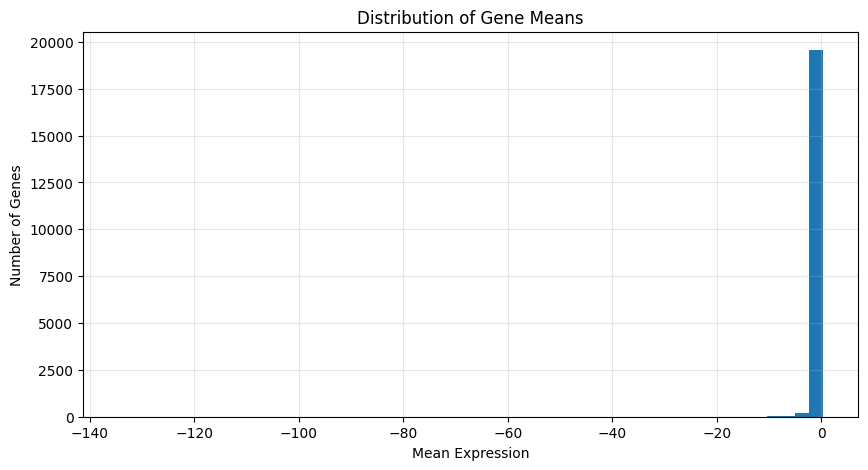

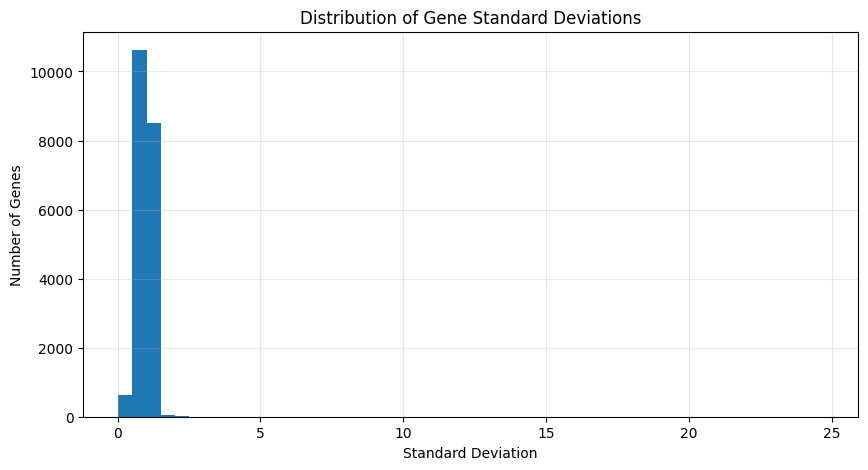

Mean expression stats:
  Min mean: -134.5041  (OR2M1P)
  Max mean: 0.2929  (NDUFB4)

Standard deviation stats:
  Min std:  0.0294  (C1orf141)
  Max std:  24.6917  (OR2M1P)


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute statistics
gene_means = mrna_df.mean(axis=0)
gene_stds = mrna_df.std(axis=0)

# 2. Plot histogram of means
plt.figure(figsize=(10,5))
plt.hist(gene_means.values, bins=50)
plt.xlabel("Mean Expression")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene Means")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Plot histogram of standard deviations
plt.figure(figsize=(10,5))
plt.hist(gene_stds.values, bins=50)
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene Standard Deviations")
plt.grid(True, alpha=0.3)
plt.show()

# Mean statistics
# Compute stats if not already computed
gene_means = mrna_df.mean(axis=0)
gene_stds = mrna_df.std(axis=0)

# Min/max means
min_mean_gene = gene_means.idxmin()
max_mean_gene = gene_means.idxmax()

# Min/max stds
min_std_gene = gene_stds.idxmin()
max_std_gene = gene_stds.idxmax()

print("Mean expression stats:")
print(f"  Min mean: {gene_means[min_mean_gene]:.4f}  ({min_mean_gene})")
print(f"  Max mean: {gene_means[max_mean_gene]:.4f}  ({max_mean_gene})")

print("\nStandard deviation stats:")
print(f"  Min std:  {gene_stds[min_std_gene]:.4f}  ({min_std_gene})")
print(f"  Max std:  {gene_stds[max_std_gene]:.4f}  ({max_std_gene})")
